<a href="https://colab.research.google.com/github/JuanCuartasCasas/ED-Desarrollo-Clases/blob/main/Clase_08/08_ED_Trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Árboles y Árboles Binarios de Búsqueda
### Universidad Nacional de Colombia
#### **Profesor:** David Alberto Herrera Alvarez
#### **Curso:** Estructuras de Datos
---

## Índice de Contenido
1. Introducción a los Árboles: Conceptos Básicos y Terminología
2. Árboles Binarios y Estructura de Nodo en Java
3. Árboles Llenos, Completos y Propiedades Matemáticas
4. Recorridos en Árboles (DFS y BFS)
5. Árboles Binarios de Búsqueda (BST)
6. Ejercicios Prácticos
7. Bibliografía y Referencias
---

## 1. Introducción a los Árboles: Conceptos Básicos y Terminología

Un **árbol (tree)** es una estructura de datos no lineal y jerárquica que consta de nodos conectados por aristas. A diferencia de arreglos, listas, pilas o colas (que son lineales), los árboles organizan los datos de manera jerárquica.

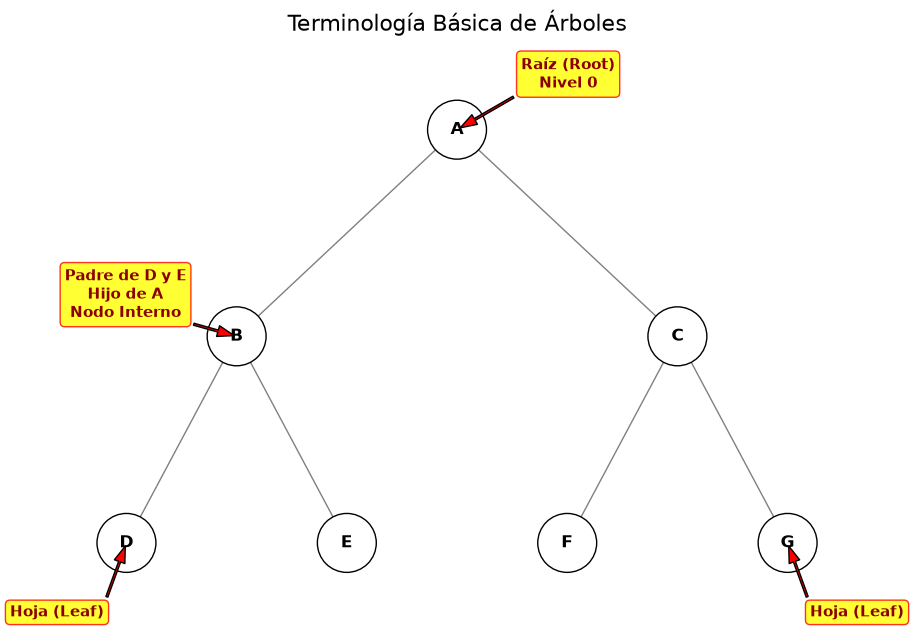
<br><em>Figura 1: Terminología y elementos de un árbol.</em>

### Terminología Principal:
- **Raíz (Root):** El nodo superior del árbol (ej. `A`). No tiene nodo padre.
- **Hijo (Child):** Un nodo conectado debajo de un nodo padre (ej. `B` y `C` son hijos de `A`).
- **Padre (Parent):** El nodo inmediato superior de cualquier nodo (ej. `B` es padre de `D` y `E`).
- **Hoja (Leaf):** Nodos que no tienen hijos (ej. `D`, `E`, `F`, `G`). Son el "final" del árbol.
- **Nodo Interno:** Nodos que tienen al menos un hijo (ej. `A`, `B`, `C`).
- **Nivel (Level):** El número de aristas desde la raíz hasta el nodo. La raíz está en el nivel 0.
- **Altura (Height):** La profundidad máxima del árbol, o la cantidad máxima de aristas desde la raíz hasta la hoja más lejana.
- **Subárbol (Subtree):** Un árbol formado por un nodo y todos sus descendientes.


## 2. Árboles Binarios y Estructura de Nodo en Java

Un **Árbol Binario** es una variante donde cada nodo tiene **como máximo dos hijos**, comúnmente llamados `izquierdo` (left) y `derecho` (right).

A continuación se muestra cómo definir y usar un nodo de árbol binario en Java:

In [ ]:
%%writefile TreeNodeDemo.java
// Definición de un Nodo de Árbol Binario
class TreeNode {
    int val;
    TreeNode left;
    TreeNode right;

    // Constructor
    public TreeNode(int x) {
        val = x;
        left = null;
        right = null;
    }
}

public class TreeNodeDemo {
    public static void main(String[] args) {
        // Creando la raíz del árbol
        TreeNode root = new TreeNode(1);

        // Agregando hijos
        root.left = new TreeNode(2);
        root.right = new TreeNode(3);

        System.out.println("Raíz: " + root.val);
        System.out.println("Hijo Izquierdo: " + root.left.val);
        System.out.println("Hijo Derecho: " + root.right.val);
    }
}


Writing TreeNodeDemo.java


In [ ]:
!javac TreeNodeDemo.java
!java TreeNodeDemo


[0.022s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.022s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Raíz: 1
Hijo Izquierdo: 2
Hijo Derecho: 3


## 3. Árboles Llenos, Completos y Propiedades Matemáticas

Es importante distinguir entre algunos tipos especiales de árboles, ya que estos presentan propiedades matemáticas extremadamente útiles (especialmente cuando lleguen al tema de **Heaps** en el futuro).

1. **Árbol Lleno (Full Binary Tree):** Cada nodo tiene exactamente 0 o 2 hijos. Nunca un solo hijo.
2. **Árbol Perfecto:** Todos los nodos internos tienen 2 hijos y todas las hojas están en el mismo nivel exacto.
3. **Árbol Completo (Complete Binary Tree):** Todos los niveles están completamente llenos, excepto posiblemente el último, el cual debe estar lleno de izquierda a derecha.

### Propiedades Matemáticas de un Árbol Binario Perfecto
Si conocemos la altura $h$ de un árbol perfecto (donde la raíz es $h=0$):
* **Nodos máximos en el nivel $L$:** $2^L$
* **Total máximo de nodos en el árbol:** $2^{h+1} - 1$
* **Número de hojas:** $2^h$

### El Árbol Sintáctico (Ejemplo de Full Tree)
Un caso de uso excelente para los árboles llenos son los **árboles de expresiones sintácticas**, donde:
- Las **hojas** representan operandos (números o variables).
- Los **nodos internos** representan operadores aritméticos.

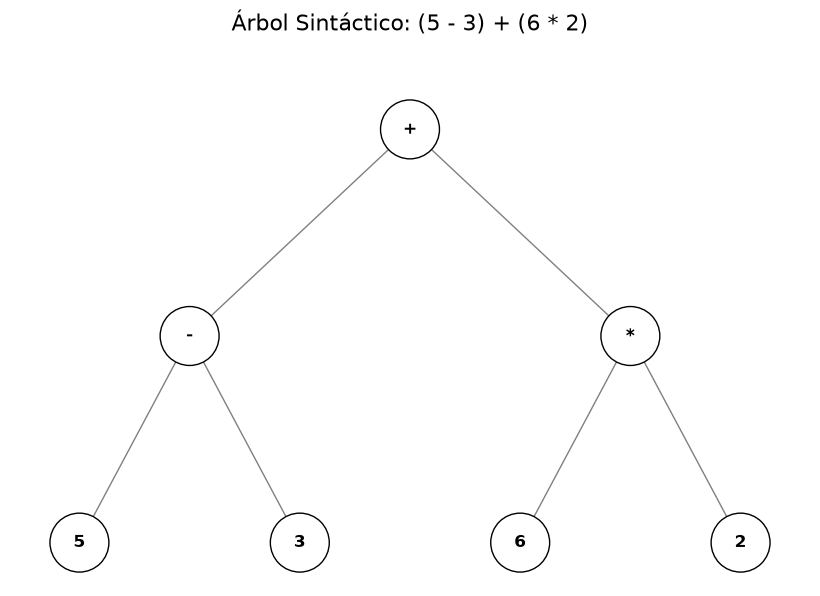
<br><em>Figura 2: Árbol sintáctico de la expresión (5 - 3) + (6 * 2)</em>


## 4. Recorridos en Árboles (DFS y BFS)

Recorrer un árbol significa visitar cada uno de sus nodos en un orden específico. Consideremos el siguiente árbol para entender los recorridos:

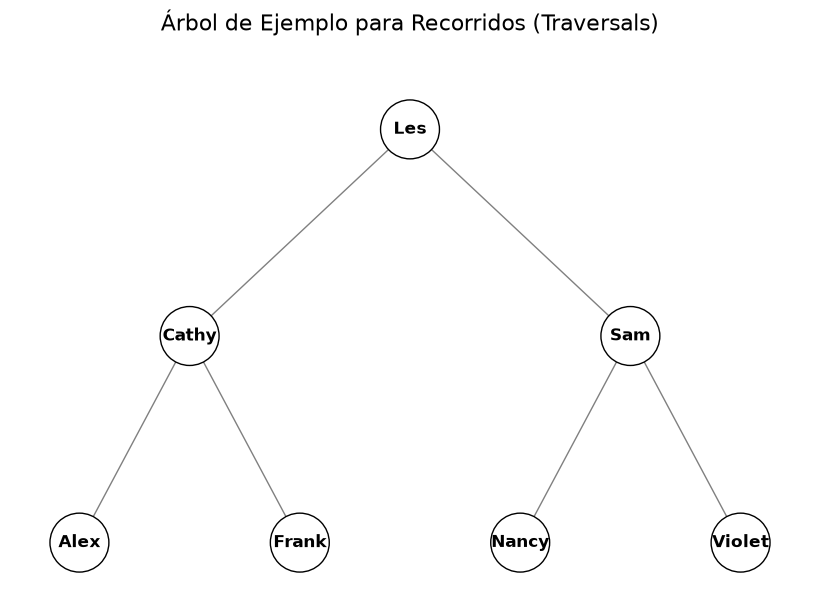
<br><em>Figura 3: Árbol de ejemplo para recorridos.</em>

### Búsqueda en Profundidad (DFS - Depth-First Search)
Explora lo más profundo posible a lo largo de cada rama antes de retroceder. Para un nodo Padre (`P`), hijo Izquierdo (`L`), hijo Derecho (`R`):

1. **In-Order (L - P - R):** Visita el subárbol izquierdo, luego el padre, luego el subárbol derecho.
   * **Ejemplo en Figura 3:** `Alex -> Cathy -> Frank -> Les -> Nancy -> Sam -> Violet`
   * *Nota: En un Binary Search Tree (BST), el recorrido In-Order imprime los valores ordenados de menor a mayor.*

2. **Pre-Order (P - L - R):** Visita el padre primero, luego el izquierdo, luego el derecho.
   * **Ejemplo en Figura 3:** `Les -> Cathy -> Alex -> Frank -> Sam -> Nancy -> Violet`
   * *Nota: Útil para crear una copia (clonar) un árbol.*

3. **Post-Order (L - R - P):** Visita los hijos izquierdo y derecho antes de procesar al padre.
   * **Ejemplo en Figura 3:** `Alex -> Frank -> Cathy -> Nancy -> Violet -> Sam -> Les`
   * *Nota: Útil para eliminar los nodos del árbol desde las hojas hacia la raíz.*

### Búsqueda en Amplitud (BFS - Breadth-First Search / Level-Order)
Visita los nodos **nivel por nivel**, de izquierda a derecha.
* **Ejemplo en Figura 3:** `Les -> Cathy -> Sam -> Alex -> Frank -> Nancy -> Violet`


In [ ]:
%%writefile TraversalsDemo.java
import java.util.LinkedList;
import java.util.Queue;

class Node {
    String val;
    Node left, right;
    public Node(String x) { val = x; left = right = null; }
}

public class TraversalsDemo {
    public static void inOrder(Node root) {
        if (root != null) {
            inOrder(root.left);
            System.out.print(root.val + " ");
            inOrder(root.right);
        }
    }

    public static void preOrder(Node root) {
        if (root != null) {
            System.out.print(root.val + " ");
            preOrder(root.left);
            preOrder(root.right);
        }
    }

    public static void postOrder(Node root) {
        if (root != null) {
            postOrder(root.left);
            postOrder(root.right);
            System.out.print(root.val + " ");
        }
    }

    public static void levelOrder(Node root) {
        if (root == null) return;
        Queue<Node> q = new LinkedList<>();
        q.add(root);

        while (!q.isEmpty()) {
            Node curr = q.poll();
            System.out.print(curr.val + " ");
            if (curr.left != null) q.add(curr.left);
            if (curr.right != null) q.add(curr.right);
        }
    }

    public static void main(String[] args) {
        // Construyendo el árbol de la Figura 3
        Node root = new Node("Les");
        root.left = new Node("Cathy");
        root.right = new Node("Sam");
        root.left.left = new Node("Alex");
        root.left.right = new Node("Frank");
        root.right.left = new Node("Nancy");
        root.right.right = new Node("Violet");

        System.out.print("In-Order:    "); inOrder(root); System.out.println();
        System.out.print("Pre-Order:   "); preOrder(root); System.out.println();
        System.out.print("Post-Order:  "); postOrder(root); System.out.println();
        System.out.print("Level-Order: "); levelOrder(root); System.out.println();
    }
}


Writing TraversalsDemo.java


In [ ]:
!javac TraversalsDemo.java
!java TraversalsDemo


[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.000s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.000s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
In-Order:    Alex Cathy Frank Les Nancy Sam Violet 
Pre-Order:   Les Cathy Alex Frank Sam Nancy Violet 
Post-Order:  Alex Frank Cathy Nancy Violet Sam Les 
Level-Order: Les Cathy Sam Alex Frank Nancy Violet 


## 5. Árboles Binarios de Búsqueda (BST)

Un **Binary Search Tree** es un árbol binario que cumple una propiedad muy importante:
Para cualquier nodo $N$, todos los valores en su subárbol izquierdo son **menores** que el valor de $N$, y todos los valores en su subárbol derecho son **mayores** que el valor de $N$.

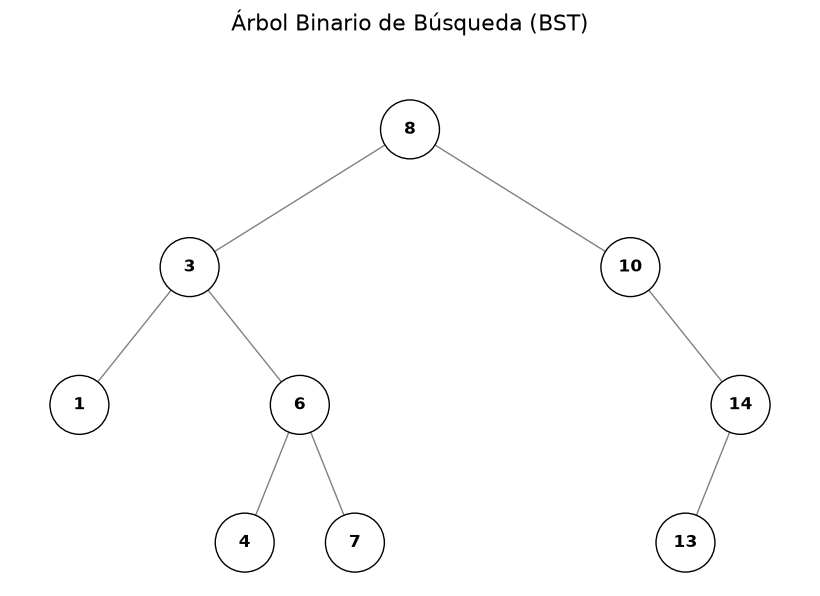
<br><em>Figura 4: Árbol Binario de Búsqueda. Observe que todos a la izquierda de 8 son menores, y a la derecha son mayores.</em>

Esto permite búsquedas e inserciones muy eficientes, con un costo promedio de $O(\log n)$.

> 💡 **Recurso Interactivo:** Para visualizar y manipular en tiempo real cómo se insertan y ordenan los nodos en un BST, te recomendamos usar el **[Data Structure Visualizer de la Universidad de San Francisco (USFCA)](https://www.cs.usfca.edu/~galles/visualization/BST.html)**. ¡Es una herramienta excelente para ver la estructura en acción!


## 6. Ejercicios Prácticos

### Ejercicio 1: Inserción en un BST y Recorrido In-Order
Completa el método `insert` para construir correctamente un BST, y luego úsalo en el método main para insertar los valores `[50, 30, 20, 40, 70, 60, 80]`.
Finalmente, completa e imprime el árbol utilizando un recorrido `In-Order` (¡deberían aparecer ordenados!).


In [3]:
%%writefile EjercicioBST.java
public class EjercicioBST {

    static class Node {
        int key;
        Node left, right;
        public Node(int item) { key = item; left = right = null; }
    }

    Node root;

    // TODO: Completa este método recursivo de inserción
    Node insertRec(Node root, int key) {
        if(root == null) return new Node(key);
        if(key < root.key){
            root.left = insertRec(root.left, key);
        } else if(key> root.key){
            root.right = insertRec(root.right, key);
        }

        // Tu código aquí
        // 1. Si el árbol está vacío, retorna un nuevo nodo con la clave
        // 2. Si la clave es menor a la raíz, inserta en el subárbol izquierdo
        // 3. Si la clave es mayor a la raíz, inserta en el subárbol derecho
        return root;
    }

    void insert(int key) {
        root = insertRec(root, key);
    }

    // TODO: Implementa el recorrido in-order (Izquierda - Raíz - Derecha)
    void inorderRec(Node root) {
        // Tu código aquí
        if(root != null){
          inorderRec(root.left);
          System.out.print(root.key + " ");
          inorderRec(root.right);

        }
    }

    void inorder() {
        inorderRec(root);
        System.out.println();
    }

    public static void main(String[] args) {
        EjercicioBST tree = new EjercicioBST();

        int[] valores = {50, 30, 20, 40, 70, 60, 80};
        for(int v : valores) {
            tree.insert(v);
        }

        System.out.print("Recorrido In-Order (debería ser ordenado ascendente): ");
        tree.inorder();
    }
}


Overwriting EjercicioBST.java


In [4]:
!javac EjercicioBST.java
!java EjercicioBST


[0.000s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.000s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.000s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
Recorrido In-Order (debería ser ordenado ascendente): 20 30 40 50 60 70 80 


### Ejercicio 2: Altura de un Árbol Binario
Implementa el método para encontrar la altura de un árbol binario. Recuerda que la altura máxima del subárbol izquierdo y el derecho más 1 da la altura total del nodo actual.


In [7]:
%%writefile EjercicioAltura.java
public class EjercicioAltura {
    static class Node {
        int val;
        Node left, right;
        public Node(int v) { val = v; }
    }

    // TODO: Implementar recursivamente el cálculo de la altura
    public static int altura(Node root) {
        if(root == null) return 0;
        int izq = altura(root.left);
        int der = altura(root.right);
        return 1 + Math.max(izq, der);
        // Tu código aquí
        // Pista: Usa Math.max(altura(root.left), altura(root.right))
    }

    public static void main(String[] args) {
        Node root = new Node(1);
        root.left = new Node(2);
        root.right = new Node(3);
        root.left.left = new Node(4);
        root.left.right = new Node(5);
        root.left.left.left = new Node(6);

        System.out.println("La altura del árbol es: " + altura(root)); // Debería imprimir 4
    }
}


Overwriting EjercicioAltura.java


In [8]:
!javac EjercicioAltura.java
!java EjercicioAltura


[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.000s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.000s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
La altura del árbol es: 4


### Ejercicio 3: Encontrar el Valor Mínimo y Máximo en un BST
Aprovechando la propiedad de los Árboles Binarios de Búsqueda (donde los menores siempre van a la izquierda y los mayores a la derecha), completa los siguientes métodos para encontrar los extremos del árbol sin tener que recorrerlo completo.


In [ ]:
%%writefile EjercicioExtremos.java
public class EjercicioExtremos {
    static class Node {
        int val;
        Node left, right;
        public Node(int v) { val = v; }
    }

    // TODO: Encontrar el valor más pequeño del BST
    public static int encontrarMinimo(Node root) {
        // Tu código aquí
        // Pista: Itera hacia la izquierda hasta que no puedas más
        return -1;
    }

    // TODO: Encontrar el valor más grande del BST
    public static int encontrarMaximo(Node root) {
        // Tu código aquí
        // Pista: Itera hacia la derecha hasta que no puedas más
        return -1;
    }

    public static void main(String[] args) {
        // Recreamos un BST simple
        Node root = new Node(20);
        root.left = new Node(10);
        root.right = new Node(30);
        root.left.left = new Node(5);
        root.left.right = new Node(15);
        root.right.right = new Node(40);

        System.out.println("El valor mínimo es: " + encontrarMinimo(root)); // Esperado: 5
        System.out.println("El valor máximo es: " + encontrarMaximo(root)); // Esperado: 40
    }
}


Writing EjercicioExtremos.java


In [ ]:
!javac EjercicioExtremos.java
!java EjercicioExtremos


[0.000s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.000s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
El valor mínimo es: -1
El valor máximo es: -1


### Ejercicio 4: Contar las Hojas de un Árbol
Escribe un método recursivo que cuente cuántos nodos hoja tiene un árbol binario. (Recuerda: Una hoja es un nodo que no tiene hijos).


In [ ]:
%%writefile EjercicioHojas.java
public class EjercicioHojas {
    static class Node {
        int val;
        Node left, right;
        public Node(int v) { val = v; }
    }

    // TODO: Cuenta y retorna la cantidad de hojas
    public static int contarHojas(Node root) {
        // Tu código aquí
        // 1. Caso base: si root es null, retorna 0
        // 2. Si root es una hoja, retorna 1
        // 3. Sino, retorna la suma de las hojas del lado izquierdo + lado derecho
        return 0;
    }

    public static void main(String[] args) {
        Node root = new Node(1);
        root.left = new Node(2);
        root.right = new Node(3);
        root.left.left = new Node(4);
        root.left.right = new Node(5);
        root.right.left = new Node(6);
        root.right.right = new Node(7);

        // Nodos 4, 5, 6 y 7 son hojas.
        System.out.println("El número de hojas es: " + contarHojas(root)); // Esperado: 4
    }
}


Writing EjercicioHojas.java


In [ ]:
!javac EjercicioHojas.java
!java EjercicioHojas


[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.000s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.000s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
El número de hojas es: 0


## 7. Bibliografía y Referencias
1. Streib, J. *Guide to Data Structures: A Concise Introduction Using Java*. Chapter 8: Trees.
2. Rhodes, N. *Data Structures and Algorithms*. Basic Data Structures: Trees.
3. Apuntes del curso "Estructuras de Datos", Universidad Nacional de Colombia.

